# Sidewalk/road classification using deep learning methods

## 0 Theory

Before we begin to implement deep learning algorithms to our data, it makes sense to understand what is in the literature. This way, we can get a grasp of the accuracy and availability of different usable models.

Based on a quick search, PointNet++ as a segmentation model appears to be popular for classifying sidewalks (Hou and Ai, 2020). PointNet++ automatically learns local geometry intrinsically, learning increasingly abstract features. CNN semantic segmentation was inaccurate in Hou and Ai (2020) because there are small elevation offsets, where CNN algorithms struggle. This is relevant for our case too. However, they trained their PointNet++ on Semantic3D. One important thing to be said here is that they use DL to simplify the geometry problem, not classify.

The part of this analyis that changes throughout the DL papers is not necessarily the segmentation, but how sidewalks are differentiated by their environment. Sidewalks can also be differentiated through subtle jumps in elevation (Horváth et al., 2021).

## 1 Methodological concepts

### 1.1. Graph based segmentation
Theoretically similar, but methodologically different, is graph based segmentation. This is - instead of treating points independently of one another, or slicing into representative stripes, the points are treated as nodes, and their connections as edges. This is useful because the computation of sidewalk vs road is not just a one point property, but a property of a region, a connected surface, and a continuous structure, hence the planing method describes earlier. With graphs, you can encode spatial continuity, smoothness constraints, label consistency, and boundary detection.

Graph segmentation splits nodes into groups such that their connections within groups are strong, and across groups is weak. Strong here can be defined on distance, normal similarity, height difference, learned embedding similarity, and semantic probabilities.

There are 3 general styles of graph based segmentation:

#### Classical graph cuts

Where: Each edge has an assigned weight. the weight is high if points are similar, and low if they are different. You then calculate a partition that minimises the cost.

#### Region growing

Starting from seed points, grow the region while keeping the normal similarity below a threshold, keeping height difference small, and curvature small. This is essentially plane/surface growing. Likely intuitive for sidewalks

#### Graph neural networks

This involves 1. Building a k-NN graph; 2. assigning features to nodes; 3. letting the network propagate features across edges; and 4. Predicting labels. Let's run through a quick example of how we'd do this:

##### Step 1 Preprocessing
- Compute per-point features:
- Coordinates
- Normals (via PCA)
- Curvature
- Height above ground
- Learned embedding

##### Step 2 build Knn graph
Each point connects to 20 nearest neighbors. Edges store:
- Distance
- Normal angle difference
- Height difference

##### Step 3 Define similarity metric

Two points are “similar” if:
- Normals aligned
- Height difference small
- Spatially close

Edge weight = combination of these.

##### Step 4 Cluster Graph

Use:
- Region growing
- Spectral clustering
- Or graph cut

To create connected planar patches so that the sidewalk becomes a large planar cluster at consistent elevation.

##### Step 5 Add a learned classifier

Cluster-level features:
- Area
- Mean normal
- Elevation offset from road
- Texture stats

Now classify cluster as:
- Road
- Sidewalk
- Roof
- Plaza
- Etc.

### 1.2. stripe-based classification

Point counts can quickly ramp up, so dividing the space into voxels (if necessary) aids with computation times. Voxels keep the LiDAR structure, random sampling removes the density consistency. Then you can sample and complete computations per voxel.

Adaptive sampling per voxel can observe is a surface is flat using PCA eigenvalues, whereby a small variation along a normal direction = a flat surface.

A label interpolation technique is required after PointNet++ prediction as there are sparse labels (i.e. 6 classes such as manmade infrastructure). So an interpolation technique based on finding neighbours using a hybrid k-nn + radius assigns a label. The radius alone would not find close neighbours in sparse regions.

Hou and Ai (2020) use stripe-based sidewalk extraction. This is geometry based where we need to separate sidewalk points from roads and grass using what we know as sidewalk characteristics (Flat, continuous, planar, consistent normal). The stripe technique (in this case, every 3ft) makes local geometry easier to reason, avoiding long range distortion of geometry.

### 0.1.1 Stripe processing

Stripe processing has two phases: Splitting and Merging.

#### Splitting (Octree + PCA)

For splitting, put each stripe into an octree, and for each node compute the PCA and check if the points are co-planar. If they are not coplanar, split into 8 smaller cubes and repeat until each node satisfies:

 $ λ_min ​≤ Δ $

 Where:
 - $λ_min$ = smallest eigenvalue of covariance
 - $Δ$ = tolerance (given measurement)

 So - Eigenvalue along normal direction = thickness of the plane. If thickness is small enough then we accept this as the plane.


#### Merging

After splitting, you have many small planar patches, if neighbouring patches have similar normals and marging still satisfies the coplanar criterion then they stay merged, therefore you have large planar surfaces inside the stripe. This works because sidewalks tend to be planar, smooth and consistent normal, whereas grass is bumpy, irregular and contains larger variation in eigenvalues.

# Code

In [1]:
import laspy
import numpy as np
import matplotlib.pyplot as plt     
import seaborn as sns
import open3d as o3d
import pandas as pd
from dotenv import load_dotenv
import json
from upath import UPath
import os
# Load environment variables from .env file if it exists
load_dotenv()
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
#from src import data_loader

sns.set_theme(style="whitegrid")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Locate to your local path. The LAS is read in some cells below
DATA_PATH = Path("/media/HDD_disk/james/lidar_REALLOCATE")
DATA_LAZ_PATH = DATA_PATH / "bologna_precalculated_subsampled.laz"

In [3]:
BOLOGNA_FILE = DATA_PATH / "bologna.laz"
RIGA_FILE = DATA_PATH / "riga.laz"

from src.helpers import describe_las
bologna = laspy.read(BOLOGNA_FILE)
riga = laspy.read(RIGA_FILE)

for name, las in [("Bologna", bologna), ("Riga", riga)]:
    print("=" * 100)
    print(f"\nLAS file: {name}")
    describe_las(las)
    print("=" * 100)


LAS file: Bologna
Point Format: <PointFormat(3, 4 bytes of extra dims)>
Number of Points: 112787346
Available Dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'height_division']
Bounding Box:
  X: -319.2701 to -107.22720000000001
  Y: -315.29970000000003 to 26.5196
  Z: -8.614600000000001 to 34.2946
Scale: [0.0001 0.0001 0.0001]
Offset: [0. 0. 0.]
CRS: None

LAS file: Riga
Point Format: <PointFormat(3, 4 bytes of extra dims)>
Number of Points: 65883275
Available Dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'height_division']
Bounding Box:
  X: -57.384

In [4]:
# check the number of points in each class
bologna_classes, bologna_counts = np.unique(bologna.classification, return_counts=True)
riga_classes, riga_counts = np.unique(riga.classification, return_counts=True)

In [5]:
print(bologna_classes, bologna_counts)
print(riga_classes, riga_counts)

[ 0  2  5  8 11 13 15] [59138239 10256476 23399428   828534 14189296   743227  4232146]
[ 0  2  3  4  5  8 11 13 15] [22746020  9215876  2054498   222812 15359527   703716 14339639     6967
  1234220]


## The challenge

The data tells us that pointclouds not only have different classes, but they also have substantially imbalanced classes. This means we will have to use a class weighting, so that smaller classes are not competely ignored.

However, for now our priority is just extracting sidewalks and roads, and so geometry models are probably going to be the better performers here.

## 2) Minimal geometry baseline (from scratch)

Goal: understand **how road and sidewalk differ geometrically** before building any classifier.

We will:
1. Use Bologna ground truth labels (`road=11`, `sidewalk=2`)
2. Compute local geometric features on a random sample
3. Compare feature distributions for road vs sidewalk

This is analysis-only (no prediction pipeline yet).

In [6]:
from src.geometry_baseline import compute_local_geometric_features, summarize_features_by_class

# Ground-truth classes confirmed for Bologna
ROAD_CLASS = 11
SIDEWALK_CLASS = 2

# Build XYZ + label arrays from Bologna
points_xyz = np.column_stack([bologna.x, bologna.y, bologna.z]).astype(np.float64)
labels_gt = np.asarray(bologna.classification)

# Compute local geometry on a sample for speed
sample_idx, feats = compute_local_geometric_features(
    points_xyz,
    k_neighbors=20,
    sample_size=300_000,
    n_jobs=-1,
)

sample_labels = labels_gt[sample_idx]
print(f'Sampled points: {sample_idx.size:,}')
print('Sampled class counts:', dict(zip(*np.unique(sample_labels, return_counts=True))))

Sampled points: 300,000
Sampled class counts: {0: 157062, 2: 27349, 5: 62271, 8: 2175, 11: 37766, 13: 1994, 15: 11383}


,class_id,class_name,feature,support,mean,median,p10,p90
4,11,road,abs_nz,37766,0.974255,0.999295,0.966088,0.999903
9,2,sidewalk,abs_nz,27349,0.965497,0.995760,0.917717,0.999622
1,11,road,curvature,37766,0.016518,0.000120,0.000020,0.067961
6,2,sidewalk,curvature,27349,0.016189,0.001763,0.000049,0.056689
3,11,road,local_height_std,37766,0.048794,0.014168,0.005683,0.164874
8,2,sidewalk,local_height_std,27349,0.060540,0.034886,0.008935,0.152926
2,11,road,roughness,37766,0.035794,0.004791,0.002096,0.136883
7,2,sidewalk,roughness,27349,0.038503,0.017403,0.002831,0.106021
0,11,road,slope_deg,37766,6.238573,2.151396,0.798847,14.964067
5,2,sidewalk,slope_deg,27349,9.737538,5.277982,1.574599,23.405457


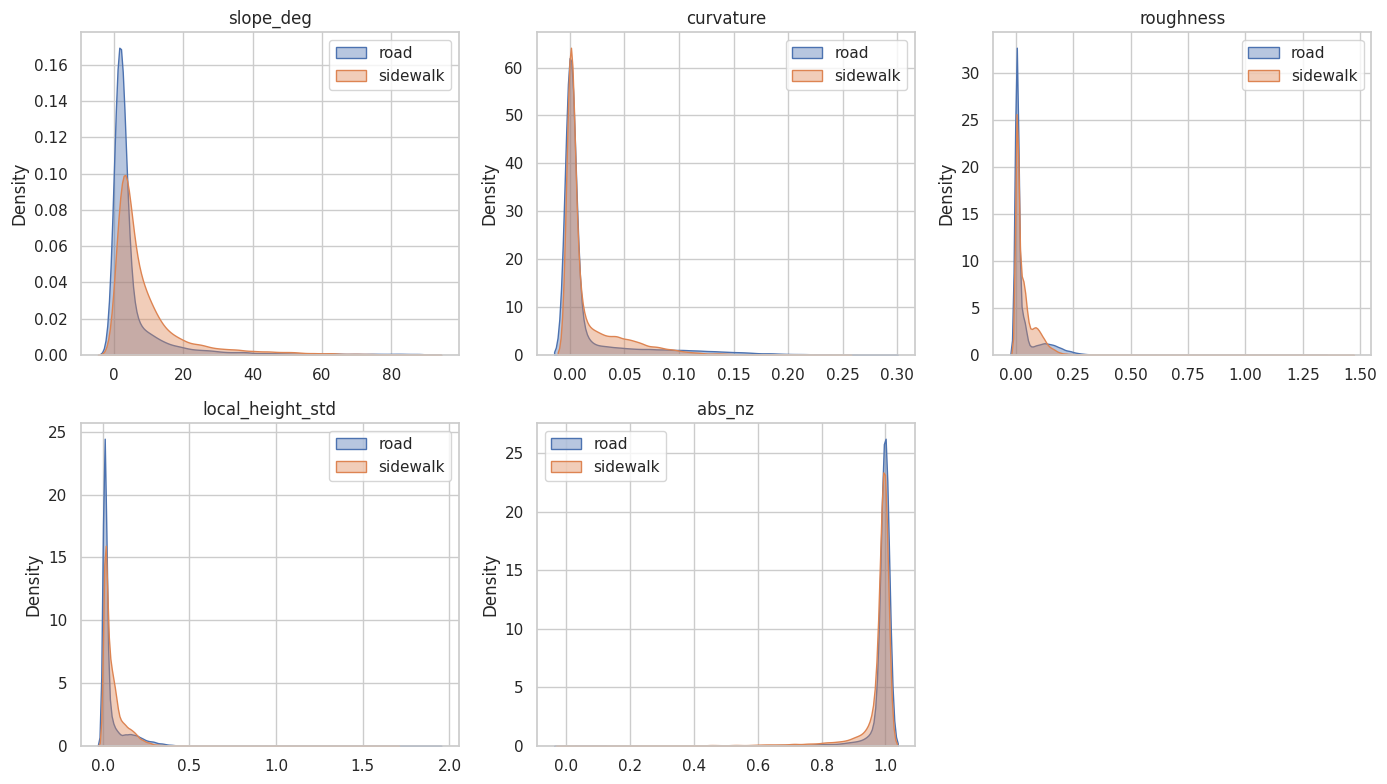

Median-difference ranking (bigger is better for separability):


,feature,road_median,sidewalk_median,abs_diff
0,slope_deg,2.151396,5.277982,3.126586
3,local_height_std,0.014168,0.034886,0.020718
2,roughness,0.004791,0.017403,0.012612
4,abs_nz,0.999295,0.995760,0.003535
1,curvature,0.000120,0.001763,0.001642


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

class_map = {ROAD_CLASS: 'road', SIDEWALK_CLASS: 'sidewalk'}
summary_df = summarize_features_by_class(feats, sample_labels, class_map)
display(summary_df.sort_values(['feature', 'class_name']))

# Plot feature distributions road vs sidewalk
plot_features = ['slope_deg', 'curvature', 'roughness', 'local_height_std', 'abs_nz']
mask_rs = np.isin(sample_labels, [ROAD_CLASS, SIDEWALK_CLASS])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, fname in enumerate(plot_features):
    ax = axes[i]
    sns.kdeplot(feats[fname][mask_rs & (sample_labels == ROAD_CLASS)], ax=ax, label='road', fill=True, alpha=0.4)
    sns.kdeplot(feats[fname][mask_rs & (sample_labels == SIDEWALK_CLASS)], ax=ax, label='sidewalk', fill=True, alpha=0.4)
    ax.set_title(fname)
    ax.legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Simple separability score (difference in medians)
sep = []
for fname in plot_features:
    road_med = float(np.median(feats[fname][mask_rs & (sample_labels == ROAD_CLASS)]))
    sw_med = float(np.median(feats[fname][mask_rs & (sample_labels == SIDEWALK_CLASS)]))
    sep.append({'feature': fname, 'road_median': road_med, 'sidewalk_median': sw_med, 'abs_diff': abs(road_med - sw_med)})

sep_df = pd.DataFrame(sep).sort_values('abs_diff', ascending=False)
print('Median-difference ranking (bigger is better for separability):')
display(sep_df)

## Minimal next stage: superpoints + context features

We now move from pointwise features to **segment-level + neighborhood-context** features.

- Build voxel superpoints from the sampled points
- Aggregate pointwise geometry into per-segment descriptors
- Add context features from nearest neighboring segments
- Train a tiny interpretable classifier on road vs sidewalk segments

In [10]:
import importlib
import src.geometry_baseline as gb

gb = importlib.reload(gb)

# point-level features for sampled points only
point_feats = {name: values for name, values in feats.items()}
sample_points = points_xyz[sample_idx]

# adaptive voxel/min_points so this works across sparse/dense scans
trials = [
    (0.30, 20),
    (0.40, 12),
    (0.60, 8),
    (0.80, 6),
    (1.00, 4),
]

superpoint_id = None
segment_df = pd.DataFrame()
labels_df = pd.DataFrame()
chosen = None

for voxel_size, min_points in trials:
    sp_id, seg_df = gb.build_superpoints_voxel(
        sample_points,
        point_feats,
        voxel_size=voxel_size,
        min_points=min_points,
    )
    lab_df = gb.assign_segment_majority_labels(sp_id, sample_labels)
    if seg_df.shape[0] > 200 and not lab_df.empty:
        superpoint_id = sp_id
        segment_df = seg_df
        labels_df = lab_df
        chosen = (voxel_size, min_points)
        break

if superpoint_id is None:
    raise RuntimeError("No usable superpoint configuration found; increase voxel_size or reduce min_points.")

segment_ctx_df = gb.build_segment_context_features(segment_df, n_neighbors=8)

print(f"Chosen params: voxel_size={chosen[0]}, min_points={chosen[1]}")
print(f"Sample points: {sample_points.shape[0]:,}")
print(f"Assigned to segments: {(superpoint_id >= 0).sum():,}")
print(f"Segments kept: {segment_df.shape[0]:,}")
print("Segment label distribution:")
print(labels_df['target_label'].value_counts().sort_index())

Chosen params: voxel_size=0.6, min_points=8
Sample points: 300,000
Assigned to segments: 56,089
Segments kept: 5,657
Segment label distribution:
target_label
0     2610
2     1208
5      209
8       39
11    1271
13      47
15     273
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import train_test_split

X, y, feature_cols, scaler = gb.prepare_segment_ml_matrix(
    segment_ctx_df=segment_ctx_df,
    labels_df=labels_df,
    keep_labels=(ROAD_CLASS, SIDEWALK_CLASS),
)

# map to binary target for easier reading: sidewalk=1, road=0
y_bin = (y == SIDEWALK_CLASS).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bin,
    test_size=0.30,
    random_state=42,
    stratify=y_bin,
)

clf = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Segment-level (road vs sidewalk) baseline")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion matrix [[road, road_pred],[sidewalk, sidewalk_pred]]:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['road', 'sidewalk']))

coef = clf.coef_.ravel()
coef_df = (
    pd.DataFrame({'feature': feature_cols, 'coef': coef, 'abs_coef': np.abs(coef)})
    .sort_values('abs_coef', ascending=False)
)
print("Top 15 logistic coefficients (magnitude):")
display(coef_df.head(15))

Segment-level (road vs sidewalk) baseline
Balanced accuracy: 0.7735

Confusion matrix [[road, road_pred],[sidewalk, sidewalk_pred]]:
[[306  75]
 [ 93 270]]

Classification report:
              precision    recall  f1-score   support

        road       0.77      0.80      0.78       381
    sidewalk       0.78      0.74      0.76       363

    accuracy                           0.77       744
   macro avg       0.77      0.77      0.77       744
weighted avg       0.77      0.77      0.77       744

Top 15 logistic coefficients (magnitude):


,feature,coef,abs_coef
17,abs_nz_mean,2.844699,2.844699
38,ctx_curvature_p90_mean,-2.078535,2.078535
27,ctx_slope_deg_median_std,-2.036478,2.036478
59,ctx_abs_nz_mean_mean,2.030040,2.030040
5,slope_deg_mean,1.772177,1.772177
60,ctx_abs_nz_mean_std,1.671726,1.671726
44,ctx_roughness_median_mean,-1.419975,1.419975
54,ctx_local_height_std_median_std,1.343683,1.343683
7,slope_deg_p90,1.190813,1.190813
30,ctx_slope_deg_p90_std,1.181026,1.181026


## Projection to points + optional graph smoothing

Now that segment-level predictions are available, we:
1) project predictions back to sampled points and visualize TP/TN/FP/FN spatially,
2) optionally apply one simple graph smoothing pass (kNN majority vote on segments) and compare metrics.

Segment-level all-RS evaluation (no smoothing):
Balanced accuracy: 0.7991
[[1057  214]
 [ 282  926]]

Point-level projected evaluation (no smoothing):
Balanced accuracy: 0.7960
[[10409  2138]
 [ 2682  8603]]
              precision    recall  f1-score   support

        road       0.80      0.83      0.81     12547
    sidewalk       0.80      0.76      0.78     11285

    accuracy                           0.80     23832
   macro avg       0.80      0.80      0.80     23832
weighted avg       0.80      0.80      0.80     23832



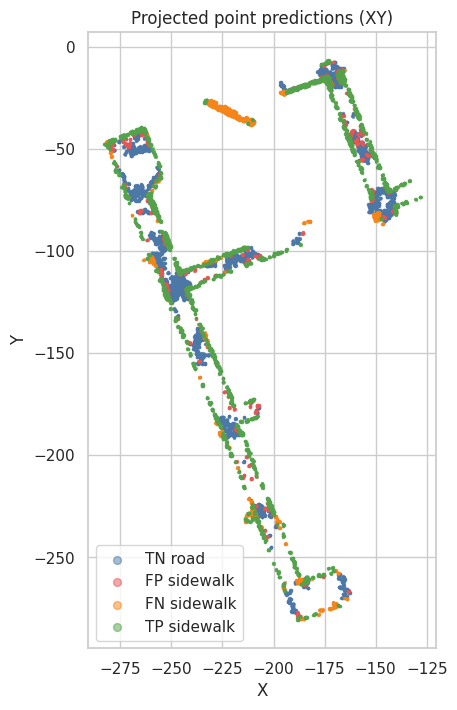

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score

# Rebuild RS segment table and predict for all RS segments
rs_seg = segment_ctx_df.merge(labels_df, on='segment_id', how='inner')
rs_seg = rs_seg[rs_seg['target_label'].isin([ROAD_CLASS, SIDEWALK_CLASS])].copy()

rs_ids = rs_seg['segment_id'].to_numpy(dtype=int)
y_rs = (rs_seg['target_label'].to_numpy(dtype=int) == SIDEWALK_CLASS).astype(int)

drop_cols = {'segment_id', 'target_label'}
rs_feature_cols = [c for c in rs_seg.columns if c not in drop_cols]
X_rs = scaler.transform(rs_seg[rs_feature_cols].to_numpy(dtype=float))
y_rs_pred = clf.predict(X_rs)

print('Segment-level all-RS evaluation (no smoothing):')
print(f"Balanced accuracy: {balanced_accuracy_score(y_rs, y_rs_pred):.4f}")
print(confusion_matrix(y_rs, y_rs_pred))

# Map segment prediction back to sampled points
seg_to_pred_bin = dict(zip(rs_ids.tolist(), y_rs_pred.tolist()))

mask_rs_points = np.isin(sample_labels, [ROAD_CLASS, SIDEWALK_CLASS])
mask_assigned = superpoint_id >= 0
mask_eval = mask_rs_points & mask_assigned

eval_seg_ids = superpoint_id[mask_eval]
valid_map = np.array([sid in seg_to_pred_bin for sid in eval_seg_ids], dtype=bool)

eval_idx = np.where(mask_eval)[0][valid_map]
point_true_bin = (sample_labels[eval_idx] == SIDEWALK_CLASS).astype(int)
point_pred_bin = np.array([seg_to_pred_bin[int(sid)] for sid in superpoint_id[eval_idx]], dtype=int)

print('\nPoint-level projected evaluation (no smoothing):')
print(f"Balanced accuracy: {balanced_accuracy_score(point_true_bin, point_pred_bin):.4f}")
print(confusion_matrix(point_true_bin, point_pred_bin))
print(classification_report(point_true_bin, point_pred_bin, target_names=['road', 'sidewalk']))

# Spatial TP/TN/FP/FN map (subsample for speed)
pts_eval = sample_points[eval_idx]
N_plot = min(2_000_000, pts_eval.shape[0])
rng = np.random.default_rng(42)
plot_sel = rng.choice(pts_eval.shape[0], size=N_plot, replace=False)

yt = point_true_bin[plot_sel]
yp = point_pred_bin[plot_sel]
pp = pts_eval[plot_sel]

code = yt * 2 + yp  # 0=TN, 1=FP, 2=FN, 3=TP
color_map = {0: '#4c78a8', 1: '#e45756', 2: '#f58518', 3: '#54a24b'}
name_map = {0: 'TN road', 1: 'FP sidewalk', 2: 'FN sidewalk', 3: 'TP sidewalk'}

fig, ax = plt.subplots(figsize=(10, 8))
for c in [0, 1, 2, 3]:
    m = code == c
    if m.any():
        ax.scatter(pp[m, 0], pp[m, 1], s=2, alpha=0.5, c=color_map[c], label=name_map[c])
ax.set_title('Projected point predictions (XY)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(markerscale=4)
ax.set_aspect('equal', adjustable='box')
plt.show()

In [13]:
from sklearn.neighbors import NearestNeighbors

# Optional: one-step graph smoothing on RS segments (majority vote over neighbors)
coords_rs = rs_seg[['cx', 'cy', 'cz']].to_numpy(dtype=float)
if coords_rs.shape[0] > 2:
    k_graph = min(8, coords_rs.shape[0] - 1)
    knn = NearestNeighbors(n_neighbors=k_graph + 1, n_jobs=-1)
    knn.fit(coords_rs)
    neigh = knn.kneighbors(coords_rs, return_distance=False)[:, 1:]

    y_smooth = y_rs_pred.copy()
    for i in range(y_rs_pred.shape[0]):
        votes = y_rs_pred[neigh[i]]
        y_smooth[i] = int(votes.mean() >= 0.5)

    print('Segment-level evaluation after 1-step graph smoothing:')
    print(f"Balanced accuracy: {balanced_accuracy_score(y_rs, y_smooth):.4f}")
    print(confusion_matrix(y_rs, y_smooth))

    seg_to_pred_smooth = dict(zip(rs_ids.tolist(), y_smooth.tolist()))
    point_pred_smooth = np.array([seg_to_pred_smooth[int(sid)] for sid in superpoint_id[eval_idx]], dtype=int)

    print('\nPoint-level projected evaluation after smoothing:')
    print(f"Balanced accuracy: {balanced_accuracy_score(point_true_bin, point_pred_smooth):.4f}")
    print(confusion_matrix(point_true_bin, point_pred_smooth))
    print(classification_report(point_true_bin, point_pred_smooth, target_names=['road', 'sidewalk']))
else:
    print('Not enough RS segments for graph smoothing.')

Segment-level evaluation after 1-step graph smoothing:
Balanced accuracy: 0.7720
[[985 286]
 [279 929]]

Point-level projected evaluation after smoothing:
Balanced accuracy: 0.7765
[[9840 2707]
 [2609 8676]]
              precision    recall  f1-score   support

        road       0.79      0.78      0.79     12547
    sidewalk       0.76      0.77      0.77     11285

    accuracy                           0.78     23832
   macro avg       0.78      0.78      0.78     23832
weighted avg       0.78      0.78      0.78     23832

